[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_24709/1084548632.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'close_smooth'] = explicit_heat_smooth(


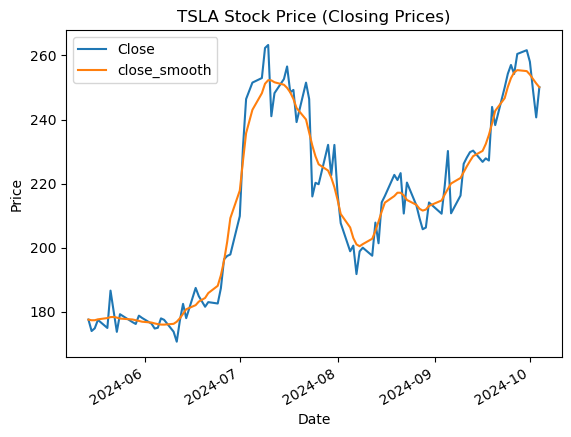

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

def explicit_heat_smooth(prices: np.array,
                         t_end: float = 3.0) -> np.array:
    '''
    Smoothen out a time series using a simple explicit finite difference method.
    The scheme uses a first-order method in time, and a second-order centred
    difference approximation in space. The scheme is only numerically stable
    if the time-step 0<=k<=1.
    
    The prices are fixed at the end-points, so the interior is smoothed.

    Parameters
    ----------
    prices : np.array
        The price to smoothen
    t_end : float
        The time at which to terminate the smootheing (i.e. t = 2)
        

    Returns
    -------
    P : np.array
        The smoothened time-series

    '''
    
    k = 0.1 # Time spacing
    
    # Set up the initial condition
    P = prices
    
    t = 0
    while t < t_end:
        # Solve the finite difference scheme for the next time-step
        P = k*(P[2:] + P[:-2]) + P[1:-1]*(1-2*k)
        
        # Add the fixed boundary conditions since the above solves the interior
        # points only
        P = np.hstack((
            np.array([prices[0]]),
            P,
            np.array([prices[-1]]),
        ))
        t += k

    return P

if __name__ == '__main__':
    df = yf.download('TSLA')
    df = df[-100:]
    
    df.loc[:, 'close_smooth'] = explicit_heat_smooth(
        df['Close'].values, 
        t_end = 3
    )
    
    df.plot(
        y = ['Close', 'close_smooth'],
        xlabel = 'Date',
        ylabel = 'Price',
        title = 'TSLA Stock Price (Closing Prices)',
    ) 